# EfficientNet-B3 (CNN) — Subtype Classification (Improved)

Upgraded two-phase training pipeline for the subtype models, built on top of the original baseline.
The baseline (single-phase, fixed LR, plain accuracy checkpointing) is kept working the same way at the data
level — same `.pkl` label files, same image directories — but the *training recipe* is substantially stronger:

**What changed vs. the baseline, and why**

| Change | Why it helps |
|---|---|
| **Two-phase training** (frozen-backbone head warm-up → full fine-tune with differential LR) | Prevents the randomly-initialized head from sending large, noisy gradients into the pretrained backbone in early steps, which is a common cause of degraded transfer-learning performance. |
| **Cosine LR schedule with linear warm-up** (phase 2) | Warm-up avoids early instability at the (higher) unfrozen LR; cosine decay lets the model settle into a sharper minimum by the end of training. |
| **Mixed precision (AMP)** | ~2x faster steps on modern GPUs, letting you fit more epochs / larger batches in the same wall-clock budget. |
| **Gradient clipping** | Stabilizes fine-tuning, particularly relevant for EfficientNet-B3. |
| **MixUp regularization** (fine-tune phase only) | Reduces overfitting to the small minority classes (e.g. DF, VASC, AK) by training on interpolated samples. |
| **RandomErasing augmentation** | Cutout-style regularization, cheap and effective on small dermoscopy datasets. |
| **Exponential Moving Average (EMA) of weights** | EMA weights are typically smoother/better generalizing than the raw end-of-epoch weights; each epoch we keep whichever (raw or EMA) scores higher on validation. |
| **Checkpointing on macro-F1 (not raw accuracy)** | These subtype tasks are class-imbalanced (e.g. NV dominates benign, MEL/BCC dominate malignant). Raw accuracy can look good while minority classes (DF, VASC, AK, SCC) are ignored. Macro-F1 / balanced accuracy weight every class equally, which is what actually matters for a screening tool. |
| **Early stopping (on macro-F1)** | Saves compute and avoids overfit once validation performance plateaus, instead of always running a fixed epoch count. |
| **Test-Time Augmentation (TTA)** at final evaluation | Averaging predictions over horizontal/vertical flips reliably adds a small but free accuracy/F1 bump at inference. |

- **Benign subtype model** — 4 classes: NV, BKL, DF, VASC
- **Malignant subtype model** — 4 classes: MEL, BCC, AK, SCC

Both use the `benign_train.pkl` / `benign_val.pkl` and `malignant_train.pkl` / `malignant_val.pkl` label files saved
to S3 in the original label-preparation notebook — no changes needed there.

> **Note:** color/hue-distorting augmentations (e.g. `TrivialAugmentWide`, solarize, invert, posterize) were
> deliberately **not** added. In dermoscopy images color is diagnostic (pigment network color, blue-white veil,
> vascular patterns), so aggressive photometric augmentation risks teaching the model color patterns that don't
> occur in real lesions. Geometric augmentation + mild color jitter + RandomErasing + MixUp give most of the
> regularization benefit without that risk.

---

### Fix applied in this revision: class-weight collapse

A first pass of this notebook produced terrible numbers (benign val accuracy ~19%, worse than the 25% you'd get
guessing randomly among 4 classes). The confusion matrix showed why: **2358 of 2495 real NV images were being
predicted as DF** — a class with only ~240 training images. The model had collapsed into spamming the rarest class.

The cause was `sklearn.utils.class_weight.compute_class_weight(..., "balanced")`, which computes raw
inverse-class-frequency weights. On this data the benign classes are extremely long-tailed (NV ≈ 17.5k train
images vs. DF ≈ 240), so "balanced" weighting produced a **~73x** weight ratio between the rarest and most common
class (`[0.30, 1.84, 21.76, 20.56]`). Combined with MixUp and fp16 autocast, that extreme ratio caused the loss
to be totally dominated by rare-class errors, so the optimizer learned to over-predict DF/VASC rather than
actually discriminate between classes — and produced sporadic `nan` batch losses along the way, a classic sign of
gradient/loss overflow.

**What changed:**
- Class weights are now computed with the **Effective Number of Samples** scheme
  ([Cui et al., CVPR 2019](https://arxiv.org/abs/1901.05555)) instead of raw inverse frequency. This weights by
  `(1 - beta) / (1 - beta^n_c)`, which grows far more gently than `1/n_c` as `n_c` shrinks — on this data it turns
  the ~73x ratio into roughly ~4-5x, enough to help the rare classes without letting them dominate the loss.
- A **weight-ratio safety cap** (`MAX_CLASS_WEIGHT_RATIO`) clips and renormalizes weights if any dataset produces
  a max/min ratio beyond a configurable threshold, as a backstop against this failure mode recurring on other
  splits.
- A **finite-loss guard** in the training loop skips (rather than silently corrupts the running average with) any
  batch whose loss comes back `nan`/`inf`, and reports how many batches were skipped per epoch — so instability
  is visible instead of quietly poisoning the printed loss curve.
- A slightly lower initial AMP loss-scale, which reduces how often fp16 overflows in the first place.


## Setup

In [1]:
import sys
sys.path.insert(0, "../../src/python/")

In [2]:
import os
import copy
import math
import pickle
import random
import warnings
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.models import efficientnet_b3
from torchvision.models import EfficientNet_B3_Weights

from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import boto3

warnings.filterwarnings("ignore")

/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [3]:
TRAIN_IMAGE_DIR = "/home/shadeform/data/train/"
VAL_IMAGE_DIR   = "/home/shadeform/data/test/"

BUCKET_NAME = "skin-lesion-data-bucket"
LABEL_PREFIX = "binary-labels"

IMAGE_SIZE = 300
BATCH_SIZE = 32

# --- Training recipe config -------------------------------------------------
CONFIG = {
    "SEED": 42,
    "HEAD_WARMUP_EPOCHS": 4,     # phase 1: backbone frozen, train head only
    "FINE_TUNE_EPOCHS": 40,      # phase 2: full fine-tune (early stopping usually ends it sooner)
    "WARMUP_EPOCHS": 3,          # linear LR warm-up epochs at the start of phase 2
    "EARLY_STOPPING_PATIENCE": 8,
    "HEAD_LR": 1e-4,             # LR for the classifier head
    "BACKBONE_LR": 1e-5,         # LR for the pretrained backbone during fine-tuning
    "WEIGHT_DECAY": 1e-4,
    "LABEL_SMOOTHING": 0.1,
    "MIXUP_ALPHA": 0.2,
    "MIXUP_PROB": 0.5,           # fraction of fine-tune batches that get MixUp
    "EMA_DECAY": 0.999,
    "GRAD_CLIP_NORM": 1.0,
    "USE_AMP": True,
    "AMP_INIT_SCALE": 2.0 ** 14,   # lower than the torch default (2**16); reduces fp16 overflow risk
    "CLASS_BALANCE_BETA": 0.999,   # effective-number-of-samples re-weighting (Cui et al. 2019)
    "MAX_CLASS_WEIGHT_RATIO": 8.0, # safety cap: clip+renormalize if max/min weight exceeds this
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["SEED"])
torch.backends.cudnn.benchmark = True

## Download Subtype Label Files (if not already local)

In [5]:
LABEL_FILES = ["benign_train.pkl", "benign_val.pkl", "malignant_train.pkl", "malignant_val.pkl"]

os.makedirs("labels", exist_ok=True)
s3 = boto3.client("s3")

for filename in LABEL_FILES:
    local_path = os.path.join("labels", filename)
    if not os.path.exists(local_path):
        s3.download_file(BUCKET_NAME, f"{LABEL_PREFIX}/{filename}", local_path)
        print("Downloaded", filename)
    else:
        print("Already present :", filename)

Already present : benign_train.pkl
Already present : benign_val.pkl
Already present : malignant_train.pkl
Already present : malignant_val.pkl


In [6]:
with open("labels/benign_train.pkl", "rb") as f:
    benign_train = pickle.load(f)
with open("labels/benign_val.pkl", "rb") as f:
    benign_val = pickle.load(f)

with open("labels/malignant_train.pkl", "rb") as f:
    malignant_train = pickle.load(f)
with open("labels/malignant_val.pkl", "rb") as f:
    malignant_val = pickle.load(f)

print("Benign    :", len(benign_train), len(benign_val))
print("Malignant :", len(malignant_train), len(malignant_val))

Benign    : 20807 3350
Malignant : 10124 4888


In [7]:
BENIGN_CLASSES = ["NV", "BKL", "DF", "VASC"]
MALIGNANT_CLASSES = ["MEL", "BCC", "AK", "SCC"]

## Transforms

In [8]:
weights = EfficientNet_B3_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

## Dataset Class

In [9]:
class MulticlassDataset(Dataset):

    def __init__(self, image_dir, labels_dict, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.labels = labels_dict
        self.image_names = list(self.labels.keys())
        print("Images :", len(self.image_names))

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        if "." in image_name:
            filename = image_name
        else:
            filename = image_name + ".jpg"
        image_path = os.path.join(self.image_dir, filename)

        if not os.path.exists(image_path):
            filename = image_name + ".png"
            image_path = os.path.join(self.image_dir, filename)

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = self.labels[image_name]
        label = int(label)

        return image, label

## Training Utilities

Helper functions used by both the benign and malignant models:
- **MixUp** — batch-level interpolation regularizer, applied only during phase-2 fine-tuning.
- **ModelEMA** — exponential moving average shadow copy of the model's weights.
- **freeze / param-group helpers** — freeze the backbone for phase 1, and build differential-LR
  param groups (`BACKBONE_LR` vs `HEAD_LR`) for phase 2.
- **warmup + cosine LR schedule** — linear warm-up for `WARMUP_EPOCHS`, then cosine decay to 0
  over the remaining fine-tune epochs.

In [10]:
HEAD_ATTR = "classifier"   # name of the classifier module on this architecture


def compute_effective_num_weights(class_counts, beta=0.999, max_ratio=8.0):
    """Class weights via the Effective Number of Samples scheme (Cui et al., CVPR 2019),
    with a safety cap on the max/min ratio. Much gentler than raw inverse-frequency
    ("balanced") weighting on long-tailed data, which can otherwise blow up to 50-100x
    and make the model collapse into over-predicting the rarest class."""
    class_counts = np.asarray(class_counts, dtype=np.float64)
    effective_num = 1.0 - np.power(beta, class_counts)
    weights = (1.0 - beta) / np.clip(effective_num, 1e-8, None)

    ratio = weights.max() / weights.min()
    if ratio > max_ratio:
        cap = weights.min() * max_ratio
        weights = np.clip(weights, None, cap)

    weights = weights / weights.sum() * len(class_counts)   # normalize to mean 1
    return weights


def mixup_batch(images, labels, alpha):
    if alpha <= 0:
        return images, labels, labels, 1.0
    lam = float(np.random.beta(alpha, alpha))
    perm = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1 - lam) * images[perm]
    return mixed, labels, labels[perm], lam


class ModelEMA:
    """Maintains an exponential moving average copy of a model's weights."""

    def __init__(self, model, decay=0.999):
        self.ema = copy.deepcopy(model).eval().to(DEVICE)
        for p in self.ema.parameters():
            p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model):
        ema_params = dict(self.ema.named_parameters())
        model_params = dict(model.named_parameters())
        for name, ema_p in ema_params.items():
            ema_p.mul_(self.decay).add_(model_params[name].detach(), alpha=1 - self.decay)

        ema_buffers = dict(self.ema.named_buffers())
        model_buffers = dict(model.named_buffers())
        for name, ema_b in ema_buffers.items():
            ema_b.copy_(model_buffers[name])


def set_backbone_trainable(model, head_attr, trainable):
    for name, param in model.named_parameters():
        if not name.startswith(head_attr):
            param.requires_grad = trainable


def build_finetune_param_groups(model, head_attr, backbone_lr, head_lr):
    backbone_params = [p for n, p in model.named_parameters() if not n.startswith(head_attr) and p.requires_grad]
    head_params = [p for n, p in model.named_parameters() if n.startswith(head_attr) and p.requires_grad]
    groups = []
    if backbone_params:
        groups.append({"params": backbone_params, "lr": backbone_lr})
    groups.append({"params": head_params, "lr": head_lr})
    return groups


def warmup_cosine_scheduler(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / max(1, warmup_epochs)
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * min(progress, 1.0)))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

## Training & Validation Functions

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, scaler,
                     ema=None, mixup_alpha=0.0, mixup_prob=0.0, grad_clip=None):

    model.train()
    running_loss = 0.0
    n_valid_batches = 0
    n_skipped = 0
    predictions, targets = [], []
    loop = tqdm(loader)

    for images, labels in loop:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        use_mixup = mixup_alpha > 0 and np.random.rand() < mixup_prob
        if use_mixup:
            mixed_images, targets_a, targets_b, lam = mixup_batch(images, labels, mixup_alpha)
        else:
            mixed_images, targets_a, targets_b, lam = images, labels, labels, 1.0

        with torch.autocast(device_type=DEVICE.type, enabled=(CONFIG["USE_AMP"] and DEVICE.type == "cuda")):
            outputs = model(mixed_images)
            loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)

        if not torch.isfinite(loss):
            # A single unstable batch (fp16 overflow, extreme weighted loss, etc.) — skip the
            # update rather than let a nan/inf poison the epoch's running loss average.
            n_skipped += 1
            loop.set_postfix(loss="skipped (non-finite)")
            continue

        scaler.scale(loss).backward()
        if grad_clip is not None:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()

        if ema is not None:
            ema.update(model)

        running_loss += loss.item()
        n_valid_batches += 1
        preds = torch.argmax(outputs, dim=1)
        predictions.extend(preds.detach().cpu().numpy())
        targets.extend(labels.cpu().numpy())
        loop.set_postfix(loss=loss.item())

    if n_skipped:
        print(f"  (skipped {n_skipped} non-finite-loss batch(es) this epoch)")

    epoch_loss = running_loss / max(1, n_valid_batches)
    epoch_acc = accuracy_score(targets, predictions) if predictions else 0.0
    return epoch_loss, epoch_acc

In [12]:
def validate(model, loader, criterion, tta=False):

    model.eval()
    running_loss = 0.0
    predictions, targets = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.autocast(device_type=DEVICE.type, enabled=(CONFIG["USE_AMP"] and DEVICE.type == "cuda")):
                if tta:
                    logits = model(images)
                    logits = logits + model(torch.flip(images, dims=[3]))   # horizontal flip
                    logits = logits + model(torch.flip(images, dims=[2]))   # vertical flip
                    outputs = logits / 3.0
                else:
                    outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            predictions.extend(preds.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(targets, predictions)
    epoch_bal_acc = balanced_accuracy_score(targets, predictions)
    epoch_f1 = f1_score(targets, predictions, average="macro")
    return epoch_loss, epoch_acc, epoch_bal_acc, epoch_f1, predictions, targets

In [13]:
def plot_confusion_matrix(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

In [14]:
def run_training(model, train_loader, val_loader, criterion, config, checkpoint_path):
    """Two-phase training: (1) head warm-up with frozen backbone, then (2) full
    fine-tune with differential LR, warm-up+cosine schedule, MixUp, EMA and
    early stopping on validation macro-F1. Whichever of (raw weights, EMA weights)
    scores higher on validation each epoch is what gets checkpointed."""

    scaler = torch.cuda.amp.GradScaler(
        enabled=(config["USE_AMP"] and DEVICE.type == "cuda"),
        init_scale=config["AMP_INIT_SCALE"])
    history = {"phase": [], "train_loss": [], "val_loss": [],
               "train_acc": [], "val_acc": [], "val_bal_acc": [], "val_f1": []}

    # ---------------- Phase 1 : head warm-up ----------------
    print("=" * 70)
    print("Phase 1 : warming up classifier head (backbone frozen)")
    print("=" * 70)
    set_backbone_trainable(model, HEAD_ATTR, trainable=False)
    head_params = [p for p in model.parameters() if p.requires_grad]
    warmup_optimizer = optim.AdamW(head_params, lr=config["HEAD_LR"], weight_decay=config["WEIGHT_DECAY"])

    for epoch in range(config["HEAD_WARMUP_EPOCHS"]):
        print(f"\n[Head warm-up] Epoch {epoch + 1}/{config['HEAD_WARMUP_EPOCHS']}")
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, warmup_optimizer, scaler,
            ema=None, mixup_alpha=0.0, mixup_prob=0.0, grad_clip=config["GRAD_CLIP_NORM"])
        val_loss, val_acc, val_bal_acc, val_f1, _, _ = validate(model, val_loader, criterion)

        print(f"Train Loss {train_loss:.4f}  Acc {train_acc * 100:.2f}%")
        print(f"Val   Loss {val_loss:.4f}  Acc {val_acc * 100:.2f}%  "
              f"BalAcc {val_bal_acc * 100:.2f}%  MacroF1 {val_f1:.4f}")

        history["phase"].append("head_warmup")
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)
        history["val_bal_acc"].append(val_bal_acc); history["val_f1"].append(val_f1)

    # ---------------- Phase 2 : full fine-tune ----------------
    print("\n" + "=" * 70)
    print("Phase 2 : fine-tuning full network")
    print("=" * 70)
    set_backbone_trainable(model, HEAD_ATTR, trainable=True)
    param_groups = build_finetune_param_groups(model, HEAD_ATTR, config["BACKBONE_LR"], config["HEAD_LR"])
    optimizer = optim.AdamW(param_groups, weight_decay=config["WEIGHT_DECAY"])
    scheduler = warmup_cosine_scheduler(optimizer, config["WARMUP_EPOCHS"], config["FINE_TUNE_EPOCHS"])
    ema = ModelEMA(model, decay=config["EMA_DECAY"])

    best_f1 = -1.0
    epochs_without_improvement = 0

    for epoch in range(config["FINE_TUNE_EPOCHS"]):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"\n[Fine-tune] Epoch {epoch + 1}/{config['FINE_TUNE_EPOCHS']}  (backbone lr={current_lr:.2e})")

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler,
            ema=ema, mixup_alpha=config["MIXUP_ALPHA"], mixup_prob=config["MIXUP_PROB"],
            grad_clip=config["GRAD_CLIP_NORM"])
        scheduler.step()

        val_loss, val_acc, val_bal_acc, val_f1, _, _ = validate(model, val_loader, criterion)
        ema_val_loss, ema_val_acc, ema_val_bal_acc, ema_val_f1, _, _ = validate(ema.ema, val_loader, criterion)

        print(f"Train Loss {train_loss:.4f}  Acc {train_acc * 100:.2f}%")
        print(f"Val      Loss {val_loss:.4f}  Acc {val_acc * 100:.2f}%  "
              f"BalAcc {val_bal_acc * 100:.2f}%  MacroF1 {val_f1:.4f}")
        print(f"Val(EMA) Loss {ema_val_loss:.4f}  Acc {ema_val_acc * 100:.2f}%  "
              f"BalAcc {ema_val_bal_acc * 100:.2f}%  MacroF1 {ema_val_f1:.4f}")

        history["phase"].append("fine_tune")
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)
        history["val_bal_acc"].append(val_bal_acc); history["val_f1"].append(val_f1)

        if ema_val_f1 >= val_f1:
            candidate_f1, candidate_state, tag = ema_val_f1, copy.deepcopy(ema.ema.state_dict()), "EMA"
        else:
            candidate_f1, candidate_state, tag = val_f1, copy.deepcopy(model.state_dict()), "raw"

        if candidate_f1 > best_f1:
            best_f1 = candidate_f1
            torch.save(candidate_state, checkpoint_path)
            epochs_without_improvement = 0
            print(f"New best model saved ({tag} weights, Macro F1 = {best_f1:.4f})")
        else:
            epochs_without_improvement += 1
            print(f"No improvement for {epochs_without_improvement} epoch(s) (best Macro F1 = {best_f1:.4f})")

        if epochs_without_improvement >= config["EARLY_STOPPING_PATIENCE"]:
            print(f"\nEarly stopping triggered after {epoch + 1} fine-tune epochs.")
            break

    return history, best_f1

---
## Benign Subtype Model (NV / BKL / DF / VASC)

### DataLoaders

In [15]:
benign_train_dataset = MulticlassDataset(TRAIN_IMAGE_DIR, benign_train, train_transform)
benign_val_dataset = MulticlassDataset(VAL_IMAGE_DIR, benign_val, val_transform)

benign_train_loader = DataLoader(benign_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=8, pin_memory=True, drop_last=True, persistent_workers=True)
benign_val_loader = DataLoader(benign_val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=8, pin_memory=True, persistent_workers=True)

print("Train :", len(benign_train_dataset), " Val :", len(benign_val_dataset))

Images : 20807
Images : 3350
Train : 20807  Val : 3350


### Model

In [16]:
weights = EfficientNet_B3_Weights.DEFAULT
NUM_CLASSES = len(BENIGN_CLASSES)

model = efficientnet_b3(weights=weights)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features, NUM_CLASSES))

benign_model = model.to(DEVICE)
print(benign_model.__class__.__name__, "ready with", NUM_CLASSES, "output classes")

EfficientNet ready with 4 output classes


### Loss

In [17]:
y_train = np.array(list(benign_train.values()))
benign_class_counts = np.bincount(y_train, minlength=len(BENIGN_CLASSES))
benign_class_weights = compute_effective_num_weights(
    benign_class_counts, beta=CONFIG["CLASS_BALANCE_BETA"], max_ratio=CONFIG["MAX_CLASS_WEIGHT_RATIO"])
benign_class_weights = torch.tensor(benign_class_weights, dtype=torch.float32).to(DEVICE)

print("Benign class counts  :", dict(zip(BENIGN_CLASSES, benign_class_counts.tolist())))
print("Benign class weights :", benign_class_weights)
print(f"Weight ratio (max/min): {(benign_class_weights.max() / benign_class_weights.min()).item():.2f}x")

benign_criterion = nn.CrossEntropyLoss(weight=benign_class_weights, label_smoothing=CONFIG["LABEL_SMOOTHING"])

Benign class counts  : {'NV': 17486, 'BKL': 2829, 'DF': 239, 'VASC': 253}
Benign class weights : tensor([0.3560, 0.3783, 1.6738, 1.5919], device='cuda:0')
Weight ratio (max/min): 4.70x


### Training

In [18]:
benign_history, benign_best_f1 = run_training(
    benign_model, benign_train_loader, benign_val_loader,
    benign_criterion, CONFIG, checkpoint_path="best_benign_efficientnet_b3.pth")

Phase 1 : warming up classifier head (backbone frozen)

[Head warm-up] Epoch 1/4


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 650/650 [01:02<00:00, 10.37it/s, loss=1.2]


Train Loss 1.2255  Acc 83.64%
Val   Loss 1.2967  Acc 78.27%  BalAcc 34.46%  MacroF1 0.3531

[Head warm-up] Epoch 2/4


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 650/650 [01:01<00:00, 10.60it/s, loss=1.2]


Train Loss 1.1733  Acc 84.77%
Val   Loss 1.2635  Acc 79.64%  BalAcc 36.67%  MacroF1 0.3689

[Head warm-up] Epoch 3/4


...

  (skipped 650 non-finite-loss batch(es) this epoch)
Train Loss 0.0000  Acc 0.00%
Val      Loss nan  Acc 74.48%  BalAcc 25.00%  MacroF1 0.2134
Val(EMA) Loss 1.0807  Acc 86.39%  BalAcc 66.45%  MacroF1 0.7067
No improvement for 6 epoch(s) (best Macro F1 = 0.7311)

[Fine-tune] Epoch 21/40  (backbone lr=5.64e-06)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 650/650 [01:09<00:00,  9.35it/s, loss=skipped (non-finite)]


  (skipped 650 non-finite-loss batch(es) this epoch)
Train Loss 0.0000  Acc 0.00%
Val      Loss nan  Acc 74.48%  BalAcc 25.00%  MacroF1 0.2134
Val(EMA) Loss 1.0807  Acc 86.39%  BalAcc 66.45%  MacroF1 0.7067
No improvement for 7 epoch(s) (best Macro F1 = 0.7311)

[Fine-tune] Epoch 22/40  (backbone lr=5.21e-06)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 650/650 [01:09<00:00,  9.32it/s, loss=skipped (non-finite)]


  (skipped 650 non-finite-loss batch(es) this epoch)
Train Loss 0.0000  Acc 0.00%
Val      Loss nan  Acc 74.48%  BalAcc 25.00%  MacroF1 0.2134
Val(EMA) Loss 1.0807  Acc 86.39%  BalAcc 66.45%  MacroF1 0.7067
No improvement for 8 epoch(s) (best Macro F1 = 0.7311)

Early stopping triggered after 22 fine-tune epochs.


### Metrics (best checkpoint, with Test-Time Augmentation)

Benign Subtype Accuracy          : 0.8734328358208955
Benign Subtype Balanced Accuracy : 0.6827541529946339
Benign Subtype Macro F1          : 0.7320782412216705

              precision    recall  f1-score   support

          NV       0.89      0.96      0.93      2495
         BKL       0.80      0.63      0.71       660
          DF       0.67      0.48      0.56        91
        VASC       0.84      0.65      0.74       104

    accuracy                           0.87      3350
   macro avg       0.80      0.68      0.73      3350
weighted avg       0.87      0.87      0.87      3350

[[2396   89    8    2]
 [ 220  418   12   10]
 [  44    2   44    1]
 [  20   14    2   68]]


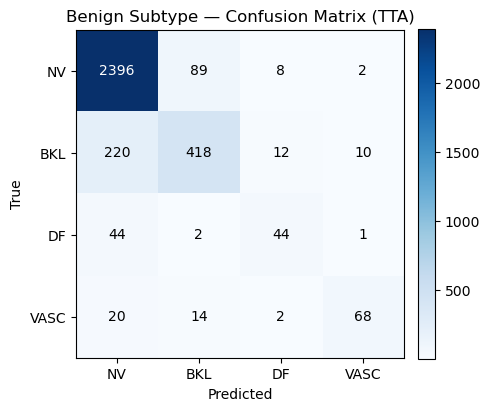

In [19]:
benign_model.load_state_dict(torch.load("best_benign_efficientnet_b3.pth", map_location=DEVICE))
benign_model.eval()

val_loss, val_acc, val_bal_acc, val_f1, predictions, targets = validate(
    benign_model, benign_val_loader, benign_criterion, tta=True)

print("Benign Subtype Accuracy          :", val_acc)
print("Benign Subtype Balanced Accuracy :", val_bal_acc)
print("Benign Subtype Macro F1          :", val_f1)
print()
print(classification_report(targets, predictions, target_names=BENIGN_CLASSES))

cm = confusion_matrix(targets, predictions)
print(cm)
plot_confusion_matrix(cm, BENIGN_CLASSES, "Benign Subtype — Confusion Matrix (TTA)")

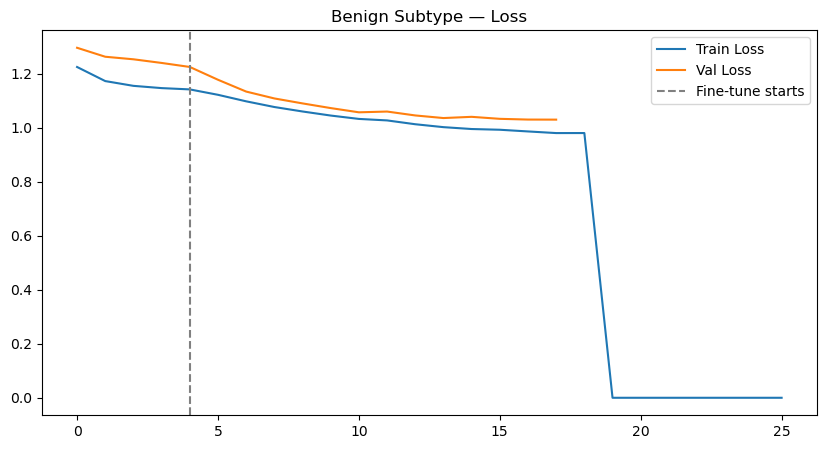

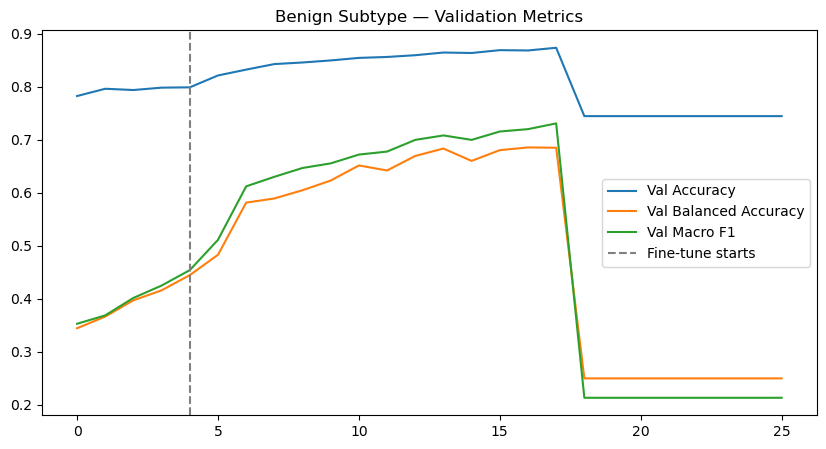

In [20]:
phase_boundary = benign_history["phase"].index("fine_tune")

plt.figure(figsize=(10, 5))
plt.plot(benign_history["train_loss"], label="Train Loss")
plt.plot(benign_history["val_loss"], label="Val Loss")
plt.axvline(phase_boundary, color="gray", linestyle="--", label="Fine-tune starts")
plt.legend()
plt.title("Benign Subtype — Loss")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(benign_history["val_acc"], label="Val Accuracy")
plt.plot(benign_history["val_bal_acc"], label="Val Balanced Accuracy")
plt.plot(benign_history["val_f1"], label="Val Macro F1")
plt.axvline(phase_boundary, color="gray", linestyle="--", label="Fine-tune starts")
plt.legend()
plt.title("Benign Subtype — Validation Metrics")
plt.show()

### Save to S3

In [21]:
os.makedirs("saved_models/efficientnet_b3_benign_subtype", exist_ok=True)

torch.save(
    {"model_state_dict": benign_model.state_dict(),
     "best_macro_f1": benign_best_f1,
     "class_names": BENIGN_CLASSES,
     "config": CONFIG},
    "saved_models/efficientnet_b3_benign_subtype/efficientnet_b3_benign_subtype_checkpoint.pth")

local_file = "saved_models/efficientnet_b3_benign_subtype/efficientnet_b3_benign_subtype_checkpoint.pth"
s3_key = f"saved_models/efficientnet_b3_benign_subtype/efficientnet_b3_benign_subtype_checkpoint.pth"
s3.upload_file(local_file, BUCKET_NAME, s3_key)
print(f"Uploaded -> s3://{BUCKET_NAME}/{s3_key}")

Uploaded -> s3://skin-lesion-data-bucket/saved_models/efficientnet_b3_benign_subtype/efficientnet_b3_benign_subtype_checkpoint.pth


---
## Malignant Subtype Model (MEL / BCC / AK / SCC)

### DataLoaders

In [22]:
malignant_train_dataset = MulticlassDataset(TRAIN_IMAGE_DIR, malignant_train, train_transform)
malignant_val_dataset = MulticlassDataset(VAL_IMAGE_DIR, malignant_val, val_transform)

malignant_train_loader = DataLoader(malignant_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                     num_workers=8, pin_memory=True, drop_last=True, persistent_workers=True)
malignant_val_loader = DataLoader(malignant_val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                                   num_workers=8, pin_memory=True, persistent_workers=True)

print("Train :", len(malignant_train_dataset), " Val :", len(malignant_val_dataset))

Images : 10124
Images : 4888
Train : 10124  Val : 4888


### Model

In [23]:
weights = EfficientNet_B3_Weights.DEFAULT
NUM_CLASSES = len(MALIGNANT_CLASSES)

model = efficientnet_b3(weights=weights)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features, NUM_CLASSES))

malignant_model = model.to(DEVICE)
print(malignant_model.__class__.__name__, "ready with", NUM_CLASSES, "output classes")

EfficientNet ready with 4 output classes


### Loss

In [24]:
y_train = np.array(list(malignant_train.values()))
malignant_class_counts = np.bincount(y_train, minlength=len(MALIGNANT_CLASSES))
malignant_class_weights = compute_effective_num_weights(
    malignant_class_counts, beta=CONFIG["CLASS_BALANCE_BETA"], max_ratio=CONFIG["MAX_CLASS_WEIGHT_RATIO"])
malignant_class_weights = torch.tensor(malignant_class_weights, dtype=torch.float32).to(DEVICE)

print("Malignant class counts  :", dict(zip(MALIGNANT_CLASSES, malignant_class_counts.tolist())))
print("Malignant class weights :", malignant_class_weights)
print(f"Weight ratio (max/min): {(malignant_class_weights.max() / malignant_class_weights.min()).item():.2f}x")

malignant_criterion = nn.CrossEntropyLoss(weight=malignant_class_weights, label_smoothing=CONFIG["LABEL_SMOOTHING"])

Malignant class counts  : {'MEL': 5321, 'BCC': 3316, 'AK': 1056, 'SCC': 431}
Malignant class weights : tensor([0.6251, 0.6454, 0.9536, 1.7759], device='cuda:0')
Weight ratio (max/min): 2.84x


### Training

In [25]:
malignant_history, malignant_best_f1 = run_training(
    malignant_model, malignant_train_loader, malignant_val_loader,
    malignant_criterion, CONFIG, checkpoint_path="best_malignant_efficientnet_b3.pth")

Phase 1 : warming up classifier head (backbone frozen)

[Head warm-up] Epoch 1/4


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 316/316 [00:39<00:00,  8.08it/s, loss=1.26]


Train Loss 1.2885  Acc 57.14%
Val   Loss 1.3268  Acc 48.85%  BalAcc 30.43%  MacroF1 0.2707

[Head warm-up] Epoch 2/4


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 316/316 [00:38<00:00,  8.19it/s, loss=1.04]


Train Loss 1.1982  Acc 66.53%
Val   Loss 1.3432  Acc 47.32%  BalAcc 33.83%  MacroF1 0.2913

[Head warm-up] Epoch 3/4


...

Train Loss 0.8394  Acc 75.00%
Val      Loss 1.3939  Acc 55.56%  BalAcc 55.24%  MacroF1 0.4442
Val(EMA) Loss 1.3946  Acc 55.59%  BalAcc 55.48%  MacroF1 0.4454
No improvement for 4 epoch(s) (best Macro F1 = 0.4455)

[Fine-tune] Epoch 39/40  (backbone lr=7.19e-08)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 316/316 [00:36<00:00,  8.75it/s, loss=0.875]


Train Loss 0.8475  Acc 74.48%
Val      Loss 1.4219  Acc 54.83%  BalAcc 54.76%  MacroF1 0.4376
Val(EMA) Loss 1.4225  Acc 54.87%  BalAcc 54.83%  MacroF1 0.4376
No improvement for 5 epoch(s) (best Macro F1 = 0.4455)

[Fine-tune] Epoch 40/40  (backbone lr=1.80e-08)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 316/316 [00:34<00:00,  9.27it/s, loss=0.615]


Train Loss 0.8317  Acc 76.05%
Val      Loss 1.4203  Acc 55.14%  BalAcc 54.91%  MacroF1 0.4404
Val(EMA) Loss 1.4205  Acc 55.14%  BalAcc 55.19%  MacroF1 0.4418
No improvement for 6 epoch(s) (best Macro F1 = 0.4455)


### Metrics (best checkpoint, with Test-Time Augmentation)

Malignant Subtype Accuracy          : 0.5495090016366612
Malignant Subtype Balanced Accuracy : 0.5631105896788103
Malignant Subtype Macro F1          : 0.44650212425280655

              precision    recall  f1-score   support

         MEL       0.91      0.48      0.63      3374
         BCC       0.39      0.83      0.53       975
          AK       0.29      0.47      0.36       374
         SCC       0.19      0.47      0.27       165

    accuracy                           0.55      4888
   macro avg       0.44      0.56      0.45      4888
weighted avg       0.73      0.55      0.58      4888

[[1623 1123  352  276]
 [  82  810   49   34]
 [  60  115  175   24]
 [  18   39   30   78]]


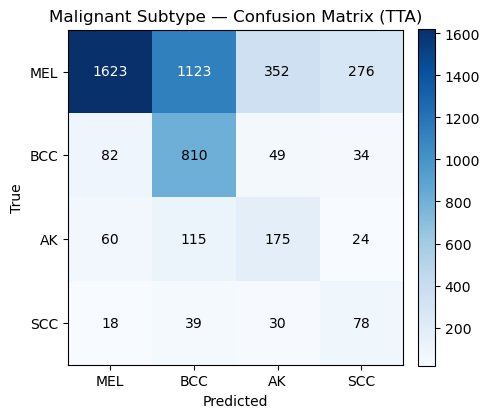

In [26]:
malignant_model.load_state_dict(torch.load("best_malignant_efficientnet_b3.pth", map_location=DEVICE))
malignant_model.eval()

val_loss, val_acc, val_bal_acc, val_f1, predictions, targets = validate(
    malignant_model, malignant_val_loader, malignant_criterion, tta=True)

print("Malignant Subtype Accuracy          :", val_acc)
print("Malignant Subtype Balanced Accuracy :", val_bal_acc)
print("Malignant Subtype Macro F1          :", val_f1)
print()
print(classification_report(targets, predictions, target_names=MALIGNANT_CLASSES))

cm = confusion_matrix(targets, predictions)
print(cm)
plot_confusion_matrix(cm, MALIGNANT_CLASSES, "Malignant Subtype — Confusion Matrix (TTA)")

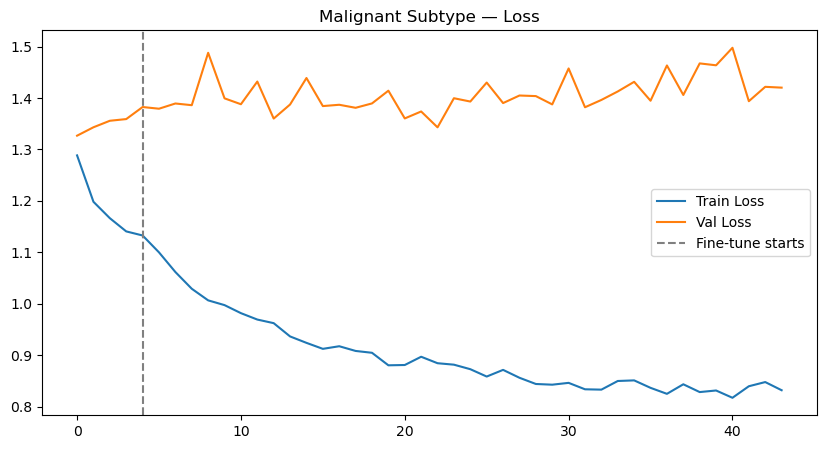

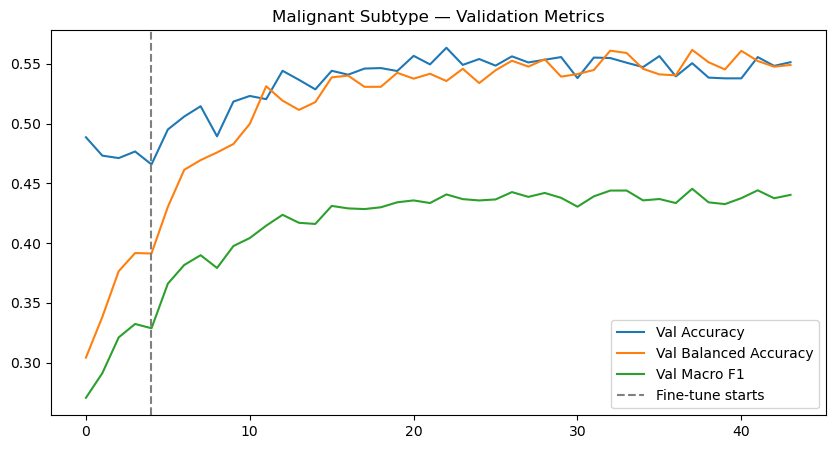

In [27]:
phase_boundary = malignant_history["phase"].index("fine_tune")

plt.figure(figsize=(10, 5))
plt.plot(malignant_history["train_loss"], label="Train Loss")
plt.plot(malignant_history["val_loss"], label="Val Loss")
plt.axvline(phase_boundary, color="gray", linestyle="--", label="Fine-tune starts")
plt.legend()
plt.title("Malignant Subtype — Loss")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(malignant_history["val_acc"], label="Val Accuracy")
plt.plot(malignant_history["val_bal_acc"], label="Val Balanced Accuracy")
plt.plot(malignant_history["val_f1"], label="Val Macro F1")
plt.axvline(phase_boundary, color="gray", linestyle="--", label="Fine-tune starts")
plt.legend()
plt.title("Malignant Subtype — Validation Metrics")
plt.show()

### Save to S3

In [28]:
os.makedirs("saved_models/efficientnet_b3_malignant_subtype", exist_ok=True)

torch.save(
    {"model_state_dict": malignant_model.state_dict(),
     "best_macro_f1": malignant_best_f1,
     "class_names": MALIGNANT_CLASSES,
     "config": CONFIG},
    "saved_models/efficientnet_b3_malignant_subtype/efficientnet_b3_malignant_subtype_checkpoint.pth")

local_file = "saved_models/efficientnet_b3_malignant_subtype/efficientnet_b3_malignant_subtype_checkpoint.pth"
s3_key = f"saved_models/efficientnet_b3_malignant_subtype/efficientnet_b3_malignant_subtype_checkpoint.pth"
s3.upload_file(local_file, BUCKET_NAME, s3_key)
print(f"Uploaded -> s3://{BUCKET_NAME}/{s3_key}")

Uploaded -> s3://skin-lesion-data-bucket/saved_models/efficientnet_b3_malignant_subtype/efficientnet_b3_malignant_subtype_checkpoint.pth


---
## Summary

Run this after both models above have trained to get a single comparison table.

In [29]:
import pandas as pd

summary = pd.DataFrame([
    {"Model": "EfficientNet-B3 — Benign", "Best Macro F1 (val)": benign_best_f1},
    {"Model": "EfficientNet-B3 — Malignant", "Best Macro F1 (val)": malignant_best_f1},
])
summary

,Model,Best Macro F1 (val)
0,EfficientNet-B3 — Benign,0.731052
1,EfficientNet-B3 — Malignant,0.445477
